# Modelo Random Forest

Random Forest: ensamble de árboles de decisión entrenados con muestreo bootstrap. Modelo no lineal y robusto para problemas tabulares. Se entrena sobre Norne con búsqueda de hiperparámetros y se evalúa contra Volve para medir transferencia cross-reservoir.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV


## 2. Feature Engineering

Construimos features adimensionales que normalizan las cantidades dependientes del tamaño del campo (producciones acumuladas, caudales) dividiendo por el pore-volume del reservorio. Esto hace que las features sean comparables entre Norne y Volve a pesar de las diferencias de escala.

In [2]:
M3_TO_BBL = 6.28981


def build_normalized_features(df: pd.DataFrame) -> pd.DataFrame:
    """Construye features adimensionales a partir del schema crudo del dataset.

    Conserva `sim_id`, `reservoir_id` y `tiempo_dias` como metadata para usar
    despues en la evaluacion y los plots. El resto son features que el modelo
    consume como input.

    Columnas que se descartan y por que
    -----------------------------------
    Bo_rb_stb, Bg_rb_scf, Rs_scf_stb : leakage del target (son funcion de la
        presion del reservorio en cada timestep).
    Espesor_Neto_m, Area               : absorbidas en el pore volume.
    Permeabilidad_mD                   : sustituida por su log10.
    """
    out = pd.DataFrame(index=df.index)

    out["sim_id"] = df["sim_id"]
    out["tiempo_dias"] = df["tiempo_dias"]
    if "reservoir_id" in df.columns:
        out["reservoir_id"] = df["reservoir_id"]
        group_keys = ["reservoir_id", "sim_id"]
    else:
        group_keys = ["sim_id"]
    g = df.groupby(group_keys)

    pv_bbl = df["Area"] * df["Espesor_Neto_m"] * df["Porosidad"] * M3_TO_BBL

    # Estaticas
    out["Porosidad"] = df["Porosidad"]
    out["log10_Permeabilidad_mD"] = np.log10(df["Permeabilidad_mD"].clip(lower=1e-3))
    out["Presion_Burbuja_psi"] = df["Presion_Burbuja_psi"]

    # Acumuladas normalizadas por pore volume
    out["Np_over_PV"] = df["Prod_Acumulada_Petroleo"] / pv_bbl
    out["Wp_over_PV"] = df["Prod_Acumulada_Agua"] / pv_bbl
    out["Winj_over_PV"] = df["Iny_Acumulada_Agua"] / pv_bbl

    # Relacion gas-petroleo acumulada
    with np.errstate(divide="ignore", invalid="ignore"):
        out["GOR_cum"] = np.where(
            df["Prod_Acumulada_Petroleo"] > 0,
            df["Prod_Acumulada_Gas"] / df["Prod_Acumulada_Petroleo"],
            0.0,
        )

    # Caudales instantaneos normalizados
    out["qo_over_PV"] = df["Caudal_Prod_Petroleo_bbl"] / pv_bbl
    out["qwinj_over_PV"] = df["Caudal_Iny_Agua_bbl"] / pv_bbl

    # WOR instantaneo: caudal de agua producida derivado del acumulado
    dt = g["tiempo_dias"].diff().replace(0, np.nan)
    wp_rate = g["Prod_Acumulada_Agua"].diff() / dt
    with np.errstate(divide="ignore", invalid="ignore"):
        out["WOR_inst"] = np.where(
            df["Caudal_Prod_Petroleo_bbl"] > 0,
            wp_rate / df["Caudal_Prod_Petroleo_bbl"],
            0.0,
        )

    # Indicadores operativos acotados
    total_liq = df["Prod_Acumulada_Petroleo"] + df["Prod_Acumulada_Agua"]
    with np.errstate(divide="ignore", invalid="ignore"):
        out["water_cut_cum"] = np.where(
            total_liq > 0, df["Prod_Acumulada_Agua"] / total_liq, 0.0
        )
        out["VRR_simple"] = np.where(
            total_liq > 0, df["Iny_Acumulada_Agua"] / total_liq, 0.0
        )

    # Presion inicial del reservorio como referencia
    out["Presion_Inicial"] = (
        df.groupby(group_keys)["Presion_Reservorio_psi"].transform("first")
    )

    # Target
    out["Presion_Reservorio_psi"] = df["Presion_Reservorio_psi"]

    return out.fillna(0.0)


## 3. Carga de datos

Cargamos los datasets de Norne y Volve directamente desde el repositorio público en GitHub y aplicamos la transformación de features a ambos.

In [3]:
NORNE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/dataset_norne.csv"
VOLVE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/dataset_volve.csv"

norne_raw = pd.read_csv(NORNE_URL)
volve_raw = pd.read_csv(VOLVE_URL)

norne_df = build_normalized_features(norne_raw)
volve_df = build_normalized_features(volve_raw)

print(f"Norne: {len(norne_df):,} filas, {norne_df['sim_id'].nunique()} simulaciones")
print(f"Volve: {len(volve_df):,} filas, {volve_df['sim_id'].nunique()} simulaciones")


Norne: 10,580 filas, 30 simulaciones
Volve: 4,144 filas, 10 simulaciones


## 4. Splits

Entrenamos sobre 24 de las 30 simulaciones de Norne, dejando 6 simulaciones para evaluación in-distribution. Las 10 simulaciones completas de Volve quedan reservadas para la evaluación cross-reservoir.

In [4]:
TRAIN_SIMS = list(range(1, 25))   # sims 1..24 de Norne (24 sims)
TEST_SIMS = list(range(25, 31))   # sims 25..30 de Norne (6 sims)

PRESSURE_SCALE = 5000.0

# Excluimos sim_id, reservoir_id y tiempo_dias del set de features (son metadata).
feature_cols = [c for c in norne_df.columns
                if c not in ["sim_id", "reservoir_id", "tiempo_dias",
                             "Presion_Reservorio_psi"]]
target_col = "Presion_Reservorio_psi"

df_train = norne_df[norne_df["sim_id"].isin(TRAIN_SIMS)].reset_index(drop=True)
df_test = norne_df[norne_df["sim_id"].isin(TEST_SIMS)].reset_index(drop=True)
df_volve = volve_df.reset_index(drop=True)

X_train = df_train[feature_cols]
y_train = df_train[target_col]
groups_train = df_train["sim_id"]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

X_volve = df_volve[feature_cols]
y_volve = df_volve[target_col]

# Target normalizado: delta de presion respecto del valor inicial, dividido por la escala fija.
# El modelo se entrena para predecir este delta. Al evaluar denormalizamos con
#     P_r_predicha = P_init + delta_pred * PRESSURE_SCALE
y_train_delta = (y_train - df_train["Presion_Inicial"]) / PRESSURE_SCALE

print(f"Train: {len(X_train):,} filas | Test (Norne): {len(X_test):,} filas | "
      f"Cross-reservoir (Volve): {len(X_volve):,} filas")
print(f"Target delta normalizado: media={y_train_delta.mean():.4f}, "
      f"std={y_train_delta.std():.4f}")

Train: 8,444 filas | Test (Norne): 2,136 filas | Cross-reservoir (Volve): 4,144 filas
Target delta normalizado: media=-0.0422, std=0.0421


## 5. Funciones de plot y evaluación

Helpers para producir métricas y plots con un formato consistente. Cada plot es una imagen independiente: una trayectoria de presión en el tiempo para una única simulación, y un parity plot global con todos los timesteps.

In [5]:
def plot_trayectoria(tiempo_dias, y_true, y_pred, titulo, nombre_archivo=None):
    """Plot único con la trayectoria de presión de una sola simulación."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(tiempo_dias, y_true, color="black", lw=1.6, label="Presión real")
    ax.plot(tiempo_dias, y_pred, color="C0", lw=1.4, linestyle="--",
            label="Presión predicha")
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel("Tiempo desde el comienzo de la producción en días")
    ax.set_ylabel("Presión (psi)")
    ax.set_title(f"{titulo} (R² = {r2:.3f}, MAE = {mae:.1f} psi)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    if nombre_archivo is not None:
        plt.savefig(nombre_archivo, dpi=150, bbox_inches="tight")
    plt.show()


def plot_parity(y_true, y_pred, titulo, nombre_archivo=None):
    """Scatter de presión real vs predicha, con la diagonal y = x de referencia."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=6, alpha=0.4, color="C0")
    lo = min(float(np.min(y_true)), float(np.min(y_pred)))
    hi = max(float(np.max(y_true)), float(np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_xlabel("Presión real (psi)")
    ax.set_ylabel("Presión predicha (psi)")
    ax.set_title(f"{titulo} (R² = {r2:.3f}, MAE = {mae:.1f} psi)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    if nombre_archivo is not None:
        plt.savefig(nombre_archivo, dpi=150, bbox_inches="tight")
    plt.show()


In [6]:
def evaluar(model, df_features, df_target, df_full, sim_ids, nombre):
    """Predice por simulacion y devuelve metricas + listas para plotear.

    El modelo predice el delta normalizado (P_r - P_init) / PRESSURE_SCALE.
    Aca lo denormalizamos a presion absoluta antes de calcular metricas y plotear:
        P_r_predicha = P_init + delta_pred * PRESSURE_SCALE
    """
    y_true_por_sim = []
    y_pred_por_sim = []
    tiempo_por_sim = []
    for sim_id in sim_ids:
        mask = df_full["sim_id"] == sim_id
        X_sim = df_features[mask]
        y_sim = df_target[mask].to_numpy()
        tiempo_sim = df_full.loc[mask, "tiempo_dias"].to_numpy()
        p_init_sim = df_full.loc[mask, "Presion_Inicial"].to_numpy()
        delta_pred = model.predict(X_sim)
        y_pred = p_init_sim + delta_pred * PRESSURE_SCALE
        y_true_por_sim.append(y_sim)
        y_pred_por_sim.append(y_pred)
        tiempo_por_sim.append(tiempo_sim)

    y_true_flat = np.concatenate(y_true_por_sim)
    y_pred_flat = np.concatenate(y_pred_por_sim)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

    print(f"=== {nombre} ===")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAE:  {mae:.2f} psi")
    print(f"  RMSE: {rmse:.2f} psi")
    return {
        "y_true_por_sim": y_true_por_sim,
        "y_pred_por_sim": y_pred_por_sim,
        "tiempo_por_sim": tiempo_por_sim,
        "y_true_flat": y_true_flat,
        "y_pred_flat": y_pred_flat,
    }

## 6. Entrenamiento

Búsqueda de hiperparámetros con `GridSearchCV` usando un esquema `GroupKFold`, que aísla cada simulación dentro de un mismo fold (evitando leakage entre timesteps de la misma simulación).

In [7]:
# Usamos GroupKFold con 5 folds: cada fold agrupa unas 4-5 sims completas
# (los timesteps de una misma sim nunca quedan partidos entre fold y otro).
gkf = GroupKFold(n_splits=5)

param_grid = {
    "n_estimators":      [200, 400],
    "max_depth":         [None, 15],
    "min_samples_split": [5, 15],
    "max_features":      ["sqrt", 0.5],
}

gs = GridSearchCV(
    RandomForestRegressor(min_samples_leaf=2, random_state=42, n_jobs=-1),
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(X_train, y_train_delta, groups=groups_train)

print(f"\nMejores hiperparámetros: {gs.best_params_}")
print(f"Mejor R² en CV sobre delta normalizado: {gs.best_score_:.4f}")

modelo_final = gs.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/mateo/Library/Python/3.13/lib/python/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/mateo/Library/Python/3.13/lib/python/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/mateo/Library/Python/3.13/lib/python/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/mateo/Library/Python/3.13/lib/python/site-packag


Mejores hiperparámetros: {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 5, 'n_estimators': 400}
Mejor R² en CV sobre delta normalizado: 0.9828


## 7. Evaluación in-distribution sobre Norne test

El modelo se evalúa sobre las 6 simulaciones de Norne que no vio durante el entrenamiento.

In [8]:
resultados_norne = evaluar(
    modelo_final, X_test, y_test, df_test, TEST_SIMS,
    nombre="Norne test (in-distribution)"
)

=== Norne test (in-distribution) ===
  R²:   0.9893
  MAE:  19.03 psi
  RMSE: 23.75 psi


Trayectoria de presión sobre una simulación representativa del set de test (la primera, sim 25).

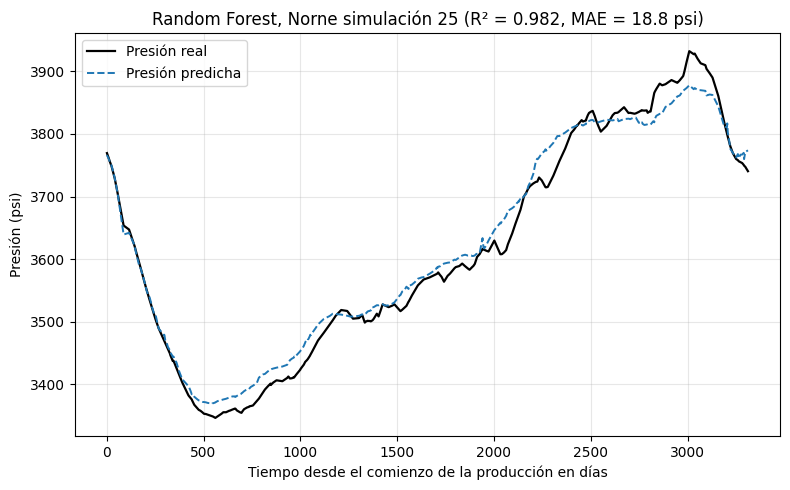

In [9]:
SIM_NORNE = TEST_SIMS[0]  # sim 25
idx = TEST_SIMS.index(SIM_NORNE)
plot_trayectoria(
    resultados_norne["tiempo_por_sim"][idx],
    resultados_norne["y_true_por_sim"][idx],
    resultados_norne["y_pred_por_sim"][idx],
    titulo=f"Random Forest, Norne simulación {SIM_NORNE}",
    nombre_archivo="random_forest_norne_trayectoria.png",
)

Parity plot global con todos los timesteps de las 6 simulaciones de test.

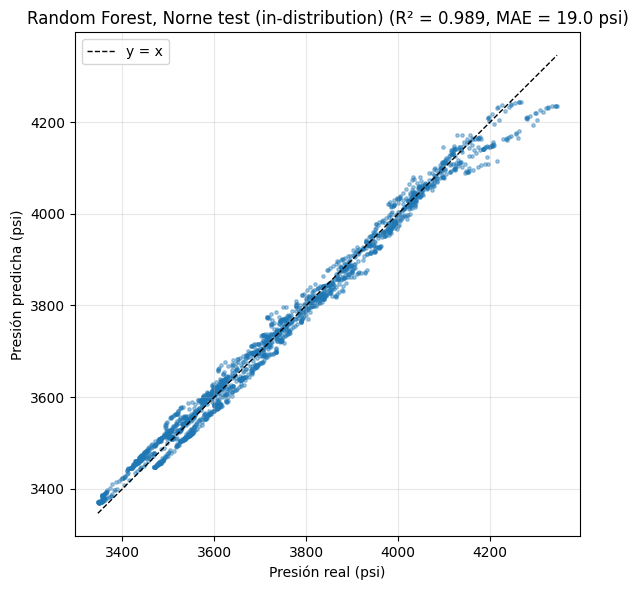

In [10]:
plot_parity(
    resultados_norne["y_true_flat"], resultados_norne["y_pred_flat"],
    titulo="Random Forest, Norne test (in-distribution)",
    nombre_archivo="random_forest_norne_parity.png",
)

## 8. Evaluación cross-reservoir sobre Volve

El modelo nunca vio Volve durante el entrenamiento. Esta evaluación mide si el modelo aprendió la física subyacente o si solamente memorizó la distribución particular de Norne.

In [11]:
VOLVE_SIMS = sorted(df_volve["sim_id"].unique().tolist())
print(f"Volve sims: {VOLVE_SIMS}")

Volve sims: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [12]:
resultados_volve = evaluar(
    modelo_final, X_volve, y_volve, df_volve, VOLVE_SIMS,
    nombre="Volve (cross-reservoir)"
)

=== Volve (cross-reservoir) ===
  R²:   0.7551
  MAE:  101.69 psi
  RMSE: 135.32 psi


Trayectoria de presión sobre una simulación de Volve (la primera, sim 1).

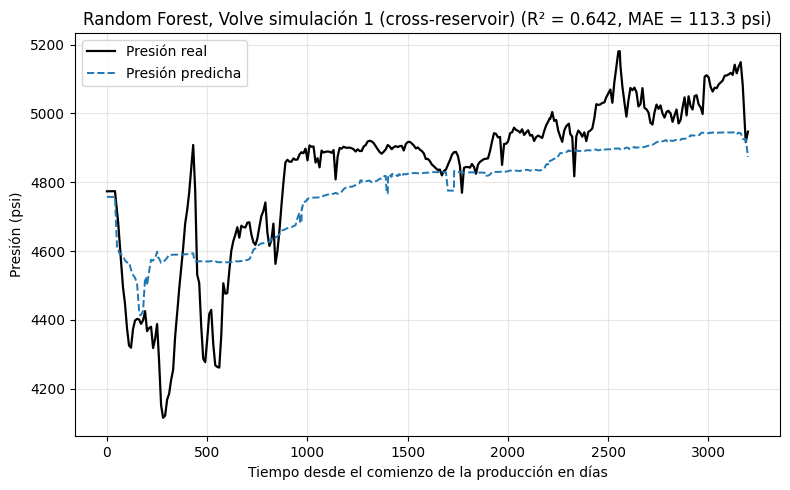

In [13]:
SIM_VOLVE = VOLVE_SIMS[0]  # sim 1
idx = VOLVE_SIMS.index(SIM_VOLVE)
plot_trayectoria(
    resultados_volve["tiempo_por_sim"][idx],
    resultados_volve["y_true_por_sim"][idx],
    resultados_volve["y_pred_por_sim"][idx],
    titulo=f"Random Forest, Volve simulación {SIM_VOLVE} (cross-reservoir)",
    nombre_archivo="random_forest_volve_trayectoria.png",
)

Parity plot global con todos los timesteps de las 10 simulaciones de Volve.

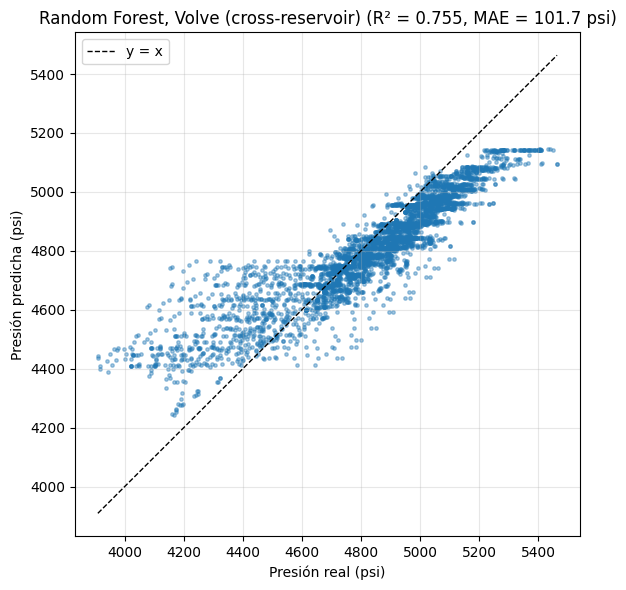

In [14]:
plot_parity(
    resultados_volve["y_true_flat"], resultados_volve["y_pred_flat"],
    titulo="Random Forest, Volve (cross-reservoir)",
    nombre_archivo="random_forest_volve_parity.png",
)